In [7]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [8]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Folder dataset:", DATASET_DIR.resolve())

Folder dataset: D:\ASUS\Documents\SEMS 4\Praktikum PCD\Projek\Project-PCD-Kelompok-16\dataset


In [9]:
data = []
labels = []
file_name = []

for class_folder in sorted(DATASET_DIR.iterdir()):
    if not class_folder.is_dir():
        continue

    label = class_folder.name
    image_files = [
        file for file in sorted(class_folder.iterdir())
        if file.suffix.lower() in VALID_EXTENSIONS
    ]

    print(f"{label}: {len(image_files)} gambar")

    for image_path in image_files:
        image = cv.imread(str(image_path))

        if image is None:
            print("Gagal membaca gambar:", image_path)
            continue

        data.append(image.astype(np.uint8))
        labels.append(label)
        file_name.append(image_path.name)

data = np.array(data, dtype=object)
labels = np.array(labels)
file_name = np.array(file_name)

print("\nTotal data:", len(data))
print(pd.Series(labels).value_counts())

catterpillar: 70 gambar
snail: 70 gambar

Total data: 140
catterpillar    70
snail           70
Name: count, dtype: int64


## Data Augmentation

### Define Augmentation Function

In [10]:
def augment_image(image):
    return []

In [11]:
USE_AUGMENTATION = False

data_used = list(data)
labels_used = list(labels)
file_name_used = list(file_name)

if USE_AUGMENTATION:
    for image, label, filename in zip(data, labels, file_name):
        for index, augmented_image in enumerate(augment_image(image), start=1):
            data_used.append(augmented_image.astype(np.uint8))
            labels_used.append(label)
            name, ext = os.path.splitext(filename)
            file_name_used.append(f"{name}_aug{index}{ext}")

data_used = np.array(data_used, dtype=object)
labels_used = np.array(labels_used)
file_name_used = np.array(file_name_used)

print("Data sebelum augmentasi:", len(data))
print("Data yang digunakan:", len(data_used))

Data sebelum augmentasi: 140
Data yang digunakan: 140


## Data Preparation



### Define Preprocessing Function

In [12]:
TARGET_SIZE = (384, 256)


def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)


def filter(img, size, mode):
    # dimensi gambar
    height, width = img.shape

    # ukuran padding
    pad = size // 2

    # tambah padding di sisi gambar
    padded = np.pad(img, pad, mode="edge")

    # canvas hasil
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:

        # FILTER RATA-RATA / MEAN FILTER
        case "mean":
            area = size * size

            for i in range(height):
                for j in range(width):

                    # area kernel
                    region = padded[i:i+size, j:j+size]

                    # hitung mean
                    canvas[i, j] = np.sum(region) / area

        # FILTER MEDIAN
        case "median":
            for i in range(height):
                for j in range(width):

                    # area kernel
                    region = padded[i:i+size, j:j+size]

                    # hitung median
                    canvas[i, j] = np.median(region)

        # FILTER MODUS / MODE FILTER
        case "modus":
            for i in range(height):
                for j in range(width):

                    # area kernel
                    region = padded[i:i+size, j:j+size]

                    # flatten array
                    values = region.ravel()

                    # hitung frekuensi
                    count = {}

                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    # cari nilai terbanyak
                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    # simpan hasil
                    canvas[i, j] = mode_val

    # kembalikan gambar
    return canvas


def prepo2(image):
    gray = resize_grayscale(image)
    median = filter(gray, 3, "median")
    return median

### Preprocessing

In [13]:
dataPreprocessed = []

for image in data_used:
    dataPreprocessed.append(prepo2(image))

dataPreprocessed = np.stack(dataPreprocessed).astype(np.uint8)

print("Jumlah data setelah preprocessing:", len(dataPreprocessed))
print("Ukuran target (width, height):", TARGET_SIZE)
print("Shape contoh gambar:", dataPreprocessed[0].shape)
print("Tipe data gambar:", dataPreprocessed.dtype)

Jumlah data setelah preprocessing: 140
Ukuran target (width, height): (384, 256)
Shape contoh gambar: (256, 384)
Tipe data gambar: uint8


### Menampilkan Gambar Dataset

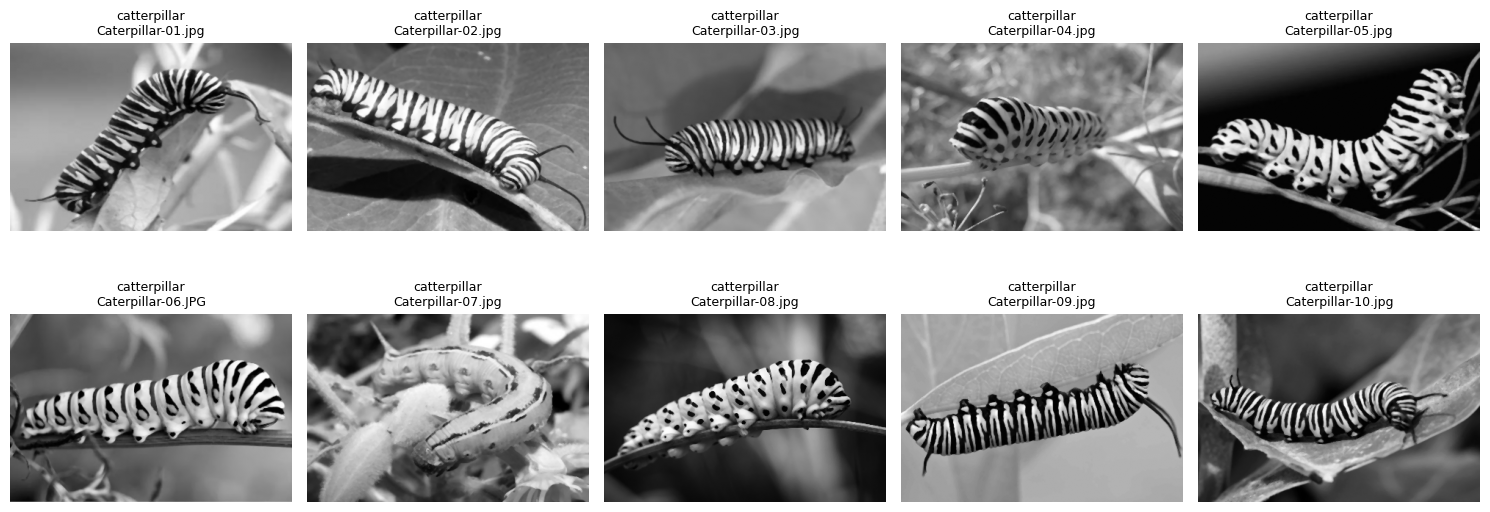

In [29]:
# Menampilkan 10 contoh gambar setelah preprocessing  resize + grayscale + median
jumlah_gambar = min(10, len(dataPreprocessed))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.axis("off")

    if i < jumlah_gambar:
        ax.imshow(dataPreprocessed[i], cmap="gray")
        ax.set_title(f"{labels_used[i]}\n{file_name_used[i]}", fontsize=9)

plt.tight_layout()
plt.show()

### Feature Extraction

In [30]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Derajat harus salah satu dari: 0, 45, 90, 135.")

    return graycomatrix(
        image,
        distances=[1],
        angles=angles,
        levels=256,
        symmetric=True,
        normed=True,
    )


def safe_value(value):
    value = float(value)
    if np.isnan(value) or np.isinf(value):
        return 0.0
    return value

In [31]:
def correlation(matriks):
    return safe_value(graycoprops(matriks, "correlation")[0, 0])


def dissimilarity(matriks):
    return safe_value(graycoprops(matriks, "dissimilarity")[0, 0])


def homogenity(matriks):
    return safe_value(graycoprops(matriks, "homogeneity")[0, 0])


def contrast(matriks):
    return safe_value(graycoprops(matriks, "contrast")[0, 0])


def ASM(matriks):
    return safe_value(graycoprops(matriks, "ASM")[0, 0])


def energy(matriks):
    return safe_value(graycoprops(matriks, "energy")[0, 0])


def entropyGlcm(matriks):
    return safe_value(entropy(matriks.ravel()))

In [32]:
def extract_glcm_features(image):
    if image.ndim == 3:
        image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    image = image.astype(np.uint8)
    features = {}

    for derajat in [0, 45, 90, 135]:
        matriks = glcm(image, derajat)
        features[f"Contrast{derajat}"] = contrast(matriks)
        features[f"Homogeneity{derajat}"] = homogenity(matriks)
        features[f"Dissimilarity{derajat}"] = dissimilarity(matriks)
        features[f"Entropy{derajat}"] = entropyGlcm(matriks)
        features[f"ASM{derajat}"] = ASM(matriks)
        features[f"Energy{derajat}"] = energy(matriks)
        features[f"Correlation{derajat}"] = correlation(matriks)

    return features

In [33]:
rows = []

for image, label, filename in zip(dataPreprocessed, labels_used, file_name_used):
    row = {
        "Filename": filename,
        "Label": label,
    }
    row.update(extract_glcm_features(image))
    rows.append(row)

hasilEkstrak = pd.DataFrame(rows)
hasilEkstrak.head()

,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,127.244686,0.532143,4.432125,7.640050,0.002426,0.049257,0.977351,229.349235,...,0.001908,0.043680,0.967759,330.261025,0.453891,6.941146,7.962432,0.001738,0.041687,0.941278
1,Caterpillar-02.jpg,catterpillar,206.083928,0.468005,5.392083,7.854042,0.001296,0.036002,0.971431,399.416997,...,0.000981,0.031322,0.970964,348.310777,0.355890,8.177054,8.351923,0.000817,0.028592,0.951789
2,Caterpillar-03.jpg,catterpillar,157.081511,0.593194,4.111252,7.216234,0.003104,0.055713,0.956494,157.284554,...,0.002933,0.054153,0.981517,260.015481,0.529772,5.620294,7.489415,0.002464,0.049644,0.928005
3,Caterpillar-04.jpg,catterpillar,86.069945,0.367824,4.302179,7.938188,0.000760,0.027566,0.973859,153.799242,...,0.000692,0.026314,0.968464,184.877960,0.293971,6.427175,8.301692,0.000538,0.023198,0.943910
4,Caterpillar-05.jpg,catterpillar,214.222656,0.610970,5.450810,6.432569,0.072459,0.269182,0.977200,377.047059,...,0.070187,0.264929,0.968375,576.237106,0.486584,9.696811,6.868323,0.068495,0.261715,0.938772


### Hasil Ekstraksi Fitur

In [34]:
print("Jumlah data hasil ekstraksi:", len(hasilEkstrak))
hasilEkstrak

Jumlah data hasil ekstraksi: 140


,Filename,Label,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,...,ASM90,Energy90,Correlation90,Contrast135,Homogeneity135,Dissimilarity135,Entropy135,ASM135,Energy135,Correlation135
0,Caterpillar-01.jpg,catterpillar,127.244686,0.532143,4.432125,7.640050,0.002426,0.049257,0.977351,229.349235,...,0.001908,0.043680,0.967759,330.261025,0.453891,6.941146,7.962432,0.001738,0.041687,0.941278
1,Caterpillar-02.jpg,catterpillar,206.083928,0.468005,5.392083,7.854042,0.001296,0.036002,0.971431,399.416997,...,0.000981,0.031322,0.970964,348.310777,0.355890,8.177054,8.351923,0.000817,0.028592,0.951789
2,Caterpillar-03.jpg,catterpillar,157.081511,0.593194,4.111252,7.216234,0.003104,0.055713,0.956494,157.284554,...,0.002933,0.054153,0.981517,260.015481,0.529772,5.620294,7.489415,0.002464,0.049644,0.928005
3,Caterpillar-04.jpg,catterpillar,86.069945,0.367824,4.302179,7.938188,0.000760,0.027566,0.973859,153.799242,...,0.000692,0.026314,0.968464,184.877960,0.293971,6.427175,8.301692,0.000538,0.023198,0.943910
4,Caterpillar-05.jpg,catterpillar,214.222656,0.610970,5.450810,6.432569,0.072459,0.269182,0.977200,377.047059,...,0.070187,0.264929,0.968375,576.237106,0.486584,9.696811,6.868323,0.068495,0.261715,0.938772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,snail (95).jpg,snail,74.263840,0.311642,5.299598,8.607113,0.000360,0.018986,0.992491,171.891169,...,0.000289,0.017004,0.987694,185.468182,0.228999,8.613813,9.063224,0.000225,0.014995,0.981242
136,snail (96).jpg,snail,43.377366,0.489466,3.065906,7.775193,0.000925,0.030407,0.992214,117.773665,...,0.000502,0.022405,0.984874,117.255742,0.315506,5.871459,8.472825,0.000463,0.021521,0.978984
137,snail (97).jpg,snail,47.822036,0.501397,3.149447,7.486838,0.004512,0.067170,0.995882,94.345753,...,0.004345,0.065913,0.996473,70.617847,0.453365,3.868059,7.691871,0.004200,0.064807,0.993920
138,snail (98).jpg,snail,17.108457,0.419646,2.515197,6.878754,0.002105,0.045885,0.989581,37.596130,...,0.001986,0.044561,0.983330,42.248472,0.340032,3.775447,7.227821,0.001534,0.039169,0.974340


### Features Selection

seleksi fitur menggunakan correlation

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 14
Fitur yang digunakan:
['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Contrast45', 'Dissimilarity45', 'Correlation45', 'Contrast90', 'Correlation90', 'Contrast135', 'Correlation135']


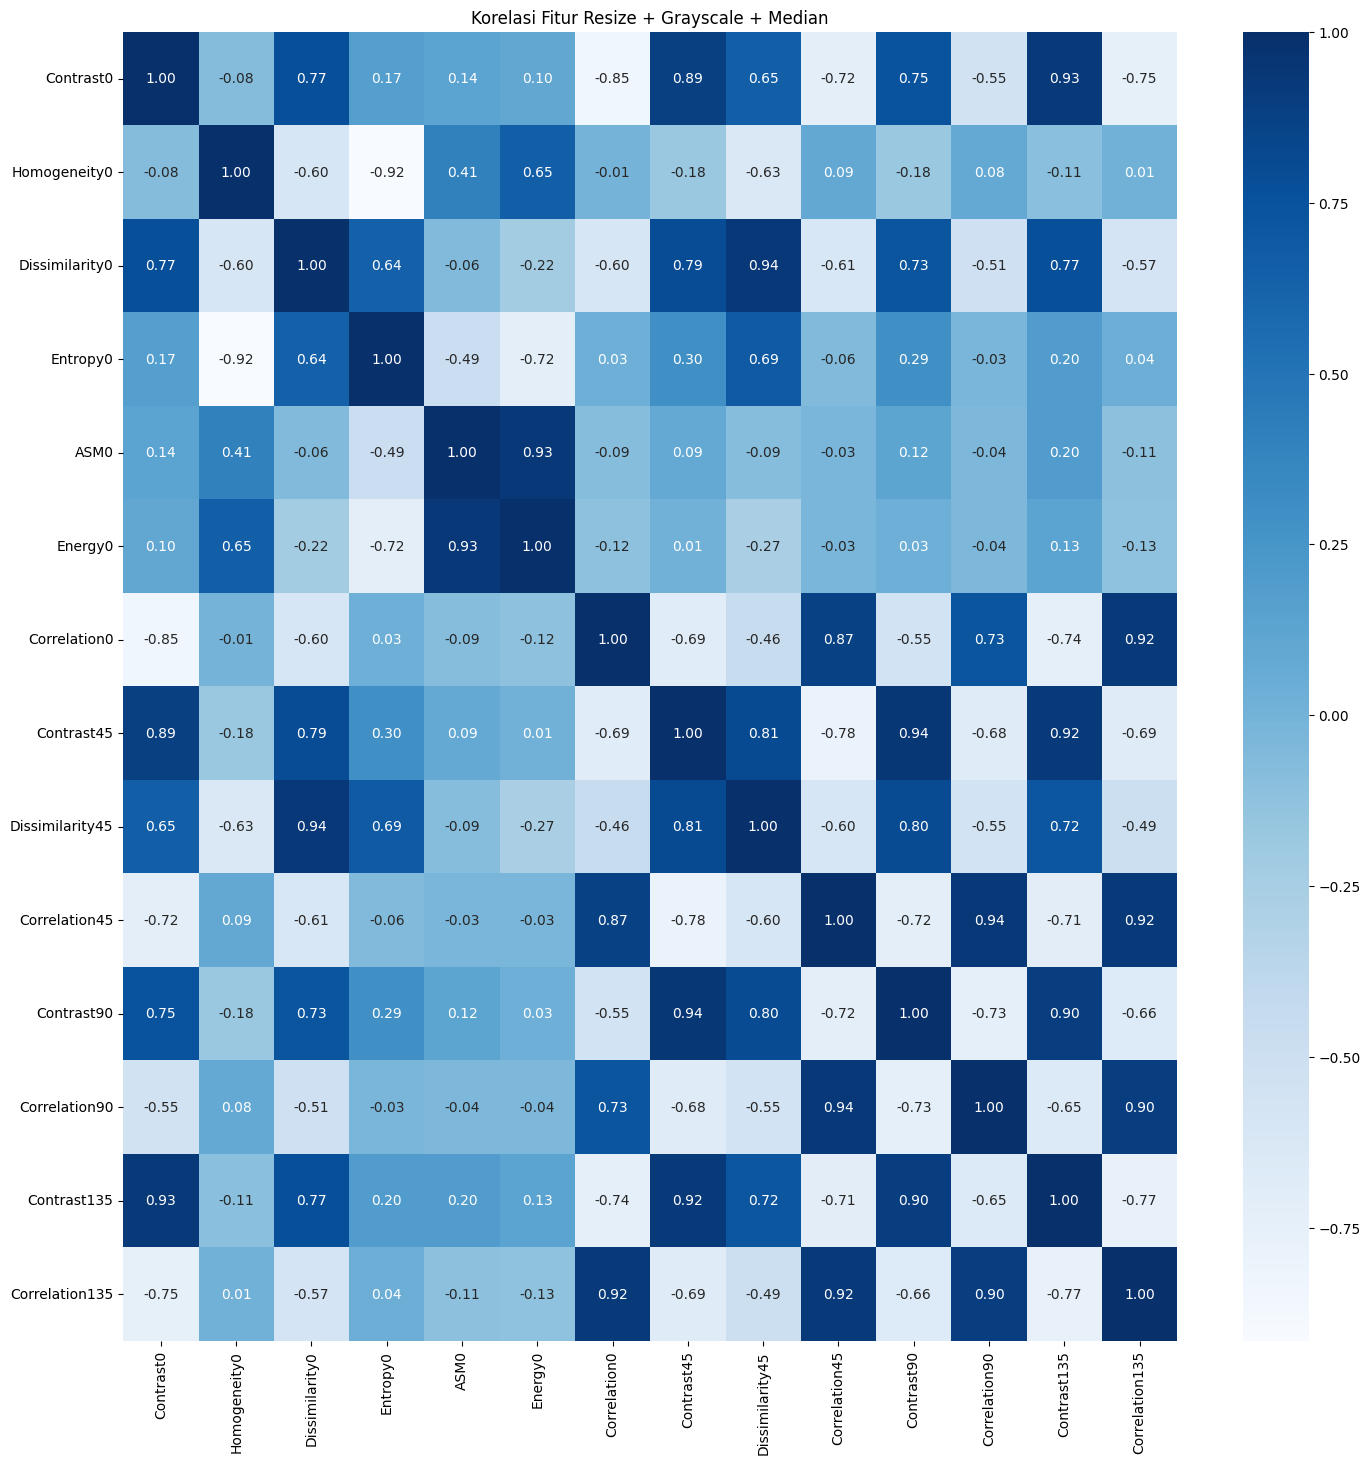

In [35]:
# Menghitung korelasi antar fitur numerik
feature_data = hasilEkstrak.drop(columns=["Label", "Filename"])
feature_data = feature_data.select_dtypes(include=[np.number])

correlation_matrix = feature_data.corr().abs()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = feature_data.columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak["Label"]

print("Jumlah fitur awal:", feature_data.shape[1])
print("Jumlah fitur setelah selection:", len(select))
print("Fitur yang digunakan:")
print(list(select))

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Korelasi Fitur Resize + Grayscale + Median")
plt.show()

## Splitting Data

In [36]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=45,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:")
print(y_train.value_counts())
print("y_test:")
print(y_test.value_counts())

X_train: (112, 14)
X_test: (28, 14)
y_train:
Label
snail           56
catterpillar    56
Name: count, dtype: int64
y_test:
Label
catterpillar    14
snail           14
Name: count, dtype: int64


## Feature Normalization


metode normalisasi menggunakan Standardization (Z-score)

In [37]:
# normalisasi mean std
std_train = X_train.std().replace(0, 1)
X_test = (X_test - X_train.mean()) / std_train
X_train = (X_train - X_train.mean()) / std_train

X_train.head()

,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Contrast45,Dissimilarity45,Correlation45,Contrast90,Correlation90,Contrast135,Correlation135
83,-0.624589,-0.102719,-0.601241,0.128171,-0.288624,-0.411752,0.879345,-0.519224,-0.342634,0.947380,-0.359344,0.876914,-0.494406,0.920712
95,-0.524101,0.243129,-0.662221,-0.253656,-0.053332,0.240659,0.851658,-0.652148,-0.738203,1.074812,-0.776707,1.179525,-0.664172,1.068062
45,-0.147398,-0.851359,0.366574,0.744907,-0.319400,-0.541155,0.005025,-0.177982,0.225286,-0.007446,0.131091,-0.449971,0.193647,-0.513089
116,-0.808701,0.449808,-1.104443,-0.530699,-0.224905,-0.193830,0.925888,-0.877270,-1.035185,1.059002,-0.931465,1.111780,-0.939591,1.098777
91,-0.524941,1.423074,-0.834247,-1.550260,0.570127,1.244801,0.428232,-0.621878,-0.916546,0.521827,-0.632125,0.502893,-0.556827,0.399236


## Modeling



### Define Model

In [38]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel="rbf", random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

hasil_model = []

### Train Random Forest Classifier

In [39]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_rf_train = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_rf_train)

print("\n------Testing Set------")
y_pred_rf_test = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf_test)

hasil_model.append({
    "Percobaan": "resize_grayscale_median",
    "Model": "Random Forest",
    "Train Accuracy": accuracy_score(y_train, y_pred_rf_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_rf_test),
    "Precision": precision_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_rf_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.95      0.96      0.96        56
       snail       0.96      0.95      0.95        56

    accuracy                           0.96       112
   macro avg       0.96      0.96      0.96       112
weighted avg       0.96      0.96      0.96       112

[[54  2]
 [ 3 53]]
Accuracy: 0.9553571428571429

------Testing Set------
              precision    recall  f1-score   support

catterpillar       1.00      0.79      0.88        14
       snail       0.82      1.00      0.90        14

    accuracy                           0.89        28
   macro avg       0.91      0.89      0.89        28
weighted avg       0.91      0.89      0.89        28

[[11  3]
 [ 0 14]]
Accuracy: 0.8928571428571429


### Train SVM Classifier

In [40]:
# Train SVM Classifier
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_svm_train = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_svm_train)

print("\n------Testing Set------")
y_pred_svm_test = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm_test)

hasil_model.append({
    "Percobaan": "resize_grayscale_median",
    "Model": "SVM",
    "Train Accuracy": accuracy_score(y_train, y_pred_svm_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_svm_test),
    "Precision": precision_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm_test, average="weighted", zero_division=0),
})

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.93      0.77      0.84        56
       snail       0.80      0.95      0.87        56

    accuracy                           0.86       112
   macro avg       0.87      0.86      0.86       112
weighted avg       0.87      0.86      0.86       112

[[43 13]
 [ 3 53]]
Accuracy: 0.8571428571428571

------Testing Set------
              precision    recall  f1-score   support

catterpillar       1.00      0.79      0.88        14
       snail       0.82      1.00      0.90        14

    accuracy                           0.89        28
   macro avg       0.91      0.89      0.89        28
weighted avg       0.91      0.89      0.89        28

[[11  3]
 [ 0 14]]
Accuracy: 0.8928571428571429


### Train KNN Classifier

In [41]:
# Train KNN Classifier
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_knn_train = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_knn_train)

print("\n------Testing Set------")
y_pred_knn_test = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn_test)

hasil_model.append({
    "Percobaan": "resize_grayscale_median",
    "Model": "KNN",
    "Train Accuracy": accuracy_score(y_train, y_pred_knn_train),
    "Test Accuracy": accuracy_score(y_test, y_pred_knn_test),
    "Precision": precision_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_knn_test, average="weighted", zero_division=0),
})

df_hasil_model = pd.DataFrame(hasil_model)
print("Ringkasan hasil klasifikasi:")
df_hasil_model

------Training Set------
              precision    recall  f1-score   support

catterpillar       0.94      0.79      0.85        56
       snail       0.82      0.95      0.88        56

    accuracy                           0.87       112
   macro avg       0.88      0.87      0.87       112
weighted avg       0.88      0.87      0.87       112

[[44 12]
 [ 3 53]]
Accuracy: 0.8660714285714286

------Testing Set------
              precision    recall  f1-score   support

catterpillar       0.93      0.93      0.93        14
       snail       0.93      0.93      0.93        14

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28

[[13  1]
 [ 1 13]]
Accuracy: 0.9285714285714286
Ringkasan hasil klasifikasi:


,Percobaan,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,resize_grayscale_median,Random Forest,0.955357,0.892857,0.911765,0.892857,0.891613
1,resize_grayscale_median,SVM,0.857143,0.892857,0.911765,0.892857,0.891613
2,resize_grayscale_median,KNN,0.866071,0.928571,0.928571,0.928571,0.928571


## Evaluation With Confusion Matrix

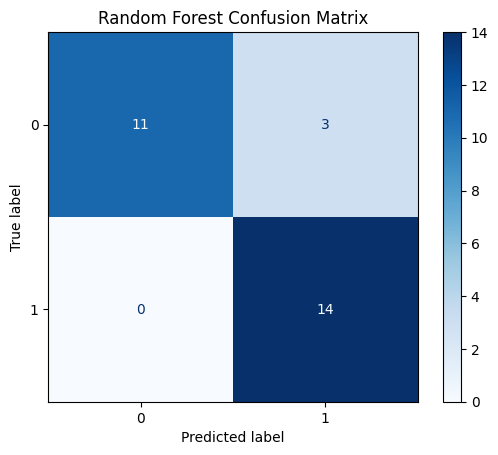

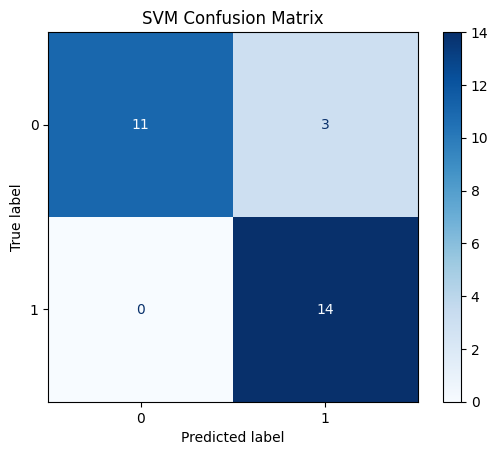

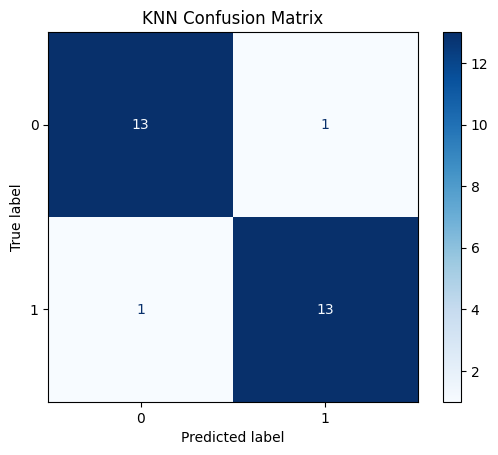

In [27]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_test, y_pred_rf_test, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_svm_test, "SVM Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN Confusion Matrix")